# Cherry CO: re-scoring the released YOLOv7 ripeness predictions with the authors' evaluation code

**Paper:** L. Cossio-Montefinale, J. Ruiz-del-Solar, R. Verschae, *"Cherry CO Dataset: A Dataset for Cherry Detection, Segmentation and Maturity Recognition"*, IEEE Robotics and Automation Letters, 2024, DOI [10.1109/LRA.2024.3393214](https://doi.org/10.1109/LRA.2024.3393214).
Project page: https://rodrigo.verschae.org/cherryCO/

**Scope (partial demonstration — evaluation only).** This notebook runs the paper's *detection-evaluation* step: it scores the authors' **released YOLOv7 ripeness predictions** (`work_dir/yolov7/` in [LuisCossioUOH/evaluation_Cherry_CO](https://github.com/LuisCossioUOH/evaluation_Cherry_CO), commit `6ed6b9f`) against the **COCO-format ground-truth test annotations** from the official dataset Drive folder, using the authors' own prediction-parsing code and the exact COCOeval parameterization of their `main.py`. It also renders one test image with ground-truth boxes vs. released predictions.

**Not included:** dataset download in full, detector training or inference (no weights are published), segmentation tasks, and the paper's published benchmark tables (the article is closed access — we *compute* metrics from released artifacts instead of quoting the paper).

**Execution status / runtime:** designed for the **CPU** Colab runtime (no torch/CUDA is used). Expected duration ≈ 4–8 min; downloads ≈ 1.1 MB gt annotation JSON + 96 MB test `images.zip` (one image is extracted) + 0.6 MB of prediction text files.

**AI-adaptation notice:** *AI-assisted adaptation for Colab; the authors did not provide this notebook. The authors' `yolo_utils_eval.py` is used verbatim; the thin mmdet-2.x wrapper around pycocotools (`main.py::evaluate_det_segm`) is replicated with pycocotools directly, keeping identical parameters (cited line-by-line). The executed example and checks were validated, but untested behavior is not guaranteed.*

**ライセンス注記 / License note:** no LICENSE file exists in the evaluation repository and no dataset license is stated on the project page; redistribution terms are unverified.

*日本語: このノートブックは Cherry CO データセット論文の「検出評価」部分を再現します。著者公開の YOLOv7 熟度予測（YOLO txt）を、Drive 上の COCO 形式テスト正解アノテーションと著者自身の評価コードのパラメータで採点します。CPU ランタイムのみ使用し、学習・推論は行いません（重みは未公開のため）。*

In [ ]:
import os, platform
print('Python      ', platform.python_version())
print('Platform    ', platform.platform())
print('CPU cores   ', os.cpu_count())
try:
    import psutil
    print('RAM (GiB)   ', round(psutil.virtual_memory().total / 2**30, 1))
except ImportError:
    print('RAM: psutil unavailable')
print('This reproduction is CPU-only: it scores released predictions against COCO')
print('annotations with pycocotools; no torch/CUDA operations are used.')

Python       3.13.16
Platform     Linux-6.6.122+-x86_64-with-glibc2.39
CPU cores    2
RAM (GiB)    12.7
This reproduction is CPU-only: it scores released predictions against COCO
annotations with pycocotools; no torch/CUDA operations are used.


#

In [ ]:
import sys, subprocess
from importlib.metadata import version

def pip(*pkgs):
    print('pip install', pkgs, flush=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('pycocotools', 'gdown')
for pkg in ['numpy', 'pycocotools', 'gdown', 'matplotlib']:
    print(f'{pkg:14s} {version(pkg)}')

pip install ('pycocotools', 'gdown')


numpy          2.1.3
pycocotools    2.0.11
gdown          5.2.2
matplotlib     3.10.0


#

In [ ]:
import hashlib, json, pathlib, urllib.request

REPO = 'LuisCossioUOH/evaluation_Cherry_CO'
COMMIT = '6ed6b9fc3a3f93cbe68b414ba5d3a83bc8087082'
RAW = f'https://raw.githubusercontent.com/{REPO}/{COMMIT}'
CODE_DIR = pathlib.Path('/content/cherryco_code')
CODE_DIR.mkdir(parents=True, exist_ok=True)

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b'blob %d\x00' % len(data) + data).hexdigest()

sha_by_path = {}
try:
    req = urllib.request.Request(
        f'https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1',
        headers={'Accept': 'application/vnd.github+json'})
    with urllib.request.urlopen(req, timeout=60) as r:
        tree = json.load(r)
    if tree.get('truncated'):
        raise RuntimeError('truncated tree listing')
    sha_by_path = {e['path']: e['sha'] for e in tree['tree'] if e['type'] == 'blob'}
    print('pinned tree files:', len(sha_by_path))
except Exception as e:
    print(f'WARNING: tree API unavailable ({e!r}); continuing without blob-SHA verification')

CODE_FILES = ['README.md', 'requirements.txt', 'main.py', 'yolo_utils_eval.py',
              'datasets/cherry_instance_ripeness.py']
for rel in CODE_FILES:
    with urllib.request.urlopen(f'{RAW}/{rel}', timeout=60) as r:
        data = r.read()
    dest = CODE_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(data)
    ok = (git_blob_sha(data) == sha_by_path[rel]) if rel in sha_by_path else None
    print(f'{rel:45s} {len(data):>7d} bytes  sha_verified={ok}')

pinned tree files: 578
README.md                                         494 bytes  sha_verified=True


requirements.txt                                   86 bytes  sha_verified=True
main.py                                         12133 bytes  sha_verified=True


yolo_utils_eval.py                               3480 bytes  sha_verified=True


datasets/cherry_instance_ripeness.py             2267 bytes  sha_verified=True


#

In [ ]:
import os

cfg_path = CODE_DIR / 'datasets' / 'cherry_instance_ripeness.py'
cfg_src = cfg_path.read_text()
print(cfg_src)

ns = {'os': os}
exec(compile(cfg_src, str(cfg_path), 'exec'), ns)
test_cfg = ns['data']['test']
ANN_BASENAME = os.path.basename(str(test_cfg['ann_file']))
CLASSES = tuple(ns.get('classes') or test_cfg.get('classes'))
print('=' * 70)
print('dataset_type :', ns.get('dataset_type'))
print('data_root    :', ns.get('data_root'))
print('test ann_file:', test_cfg.get('ann_file'))
print('test img_prefix:', test_cfg.get('img_prefix'))
print('classes      :', CLASSES)

dataset_type = 'SingleClassDataset'

data_root = '/home/luis/2021/COCO/cherry_dataset3/'

classes = ('ripe', 'unripe', 'green')
img_norm_cfg = dict(
    mean=[123.675, 116.28, 103.53], std=[58.395, 57.12, 57.375], to_rgb=True)
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='Resize', img_scale=(1024, 1024), keep_ratio=True),
    dict(type='RandomFlip', flip_ratio=0.5),
    dict(type='Normalize', **img_norm_cfg),
    dict(type='Pad', size_divisor=8, pad_val=114),
    dict(type='DefaultFormatBundle'),
    dict(type='Collect', keys=['img', 'gt_bboxes', 'gt_labels', 'gt_masks']),
]
test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(
        type='MultiScaleFlipAug',
        img_scale=(1024, 1024),
        flip=False,
        transforms=[
            dict(type='Resize', img_scale=(1024, 1024), keep_ratio=True),
            # dict(type='RandomFlip'),
            dict(type='Normalize', **img_nor

#

In [ ]:
import re

DRIVE_FOLDER_ID = '1_-sOfq6KC62i9_rKeMwwGba5uBOaagaj'

def list_drive_folder(fid):
    url = f'https://drive.google.com/embeddedfolderview?id={fid}#list'
    with urllib.request.urlopen(url, timeout=60) as r:
        html = r.read().decode('utf-8', 'replace')
    entries = []
    for m in re.finditer(r'<div class="flip-entry" id="entry-([\w-]+)"[\s\S]*?<div class="flip-entry-title">([^<]*)</div>', html):
        entry_id, name, block = m.group(1), m.group(2), m.group(0)
        if 'drive.google.com/drive/folders/' in block:
            kind = 'folder'
        elif '/file/d/' in block:
            kind = 'file'
        else:
            kind = 'unknown'
        entries.append((entry_id, name, kind))
    return entries

root_entries = list_drive_folder(DRIVE_FOLDER_ID)
print(f'{len(root_entries)} entries at the Drive root:')
for entry_id, name, kind in root_entries:
    print(f'  [{kind:6s}] {name}  ({entry_id})')
test_folders = [e for e in root_entries if e[2] == 'folder' and e[1].strip().lower() == 'test']
assert len(test_folders) == 1, f'expected exactly one "test" subfolder, got {test_folders}'
TEST_FOLDER_ID = test_folders[0][0]
print('\nTEST_FOLDER_ID =', TEST_FOLDER_ID)

4 entries at the Drive root:
  [folder] original  (18rtJ9PiW9cw4pyu0pDSg3ZHYlsOtpWzH)
  [folder] test  (1qsBuLJZNGR4ynSeCcsx_SUMCWtVARD18)
  [folder] train  (1n-hU0FzWlfGLN4_6S8BqQoZ8jr2PlRrX)
  [folder] val  (1atxZBPIK4-PFl4giU-aIAm3VaqGEiimZ)

TEST_FOLDER_ID = 1qsBuLJZNGR4ynSeCcsx_SUMCWtVARD18


#

In [ ]:
import gdown

test_entries = list_drive_folder(TEST_FOLDER_ID)
print('entries in the test split:')
for entry_id, name, kind in test_entries:
    print(f'  [{kind:6s}] {name}  ({entry_id})')
json_entries = [e for e in test_entries if e[2] == 'file' and e[1].lower().endswith('.json')]
assert json_entries, 'no .json annotation file in the test split'
ann_entry = ([e for e in json_entries if 'ripeness' in e[1].lower()] or
             [e for e in json_entries if e[1] == ANN_BASENAME] or json_entries)[0]
print('selected gt annotation:', ann_entry[1])
gdown.download(id=ann_entry[0], output='/content/instances_test_ripeness.json', quiet=True)
ANN_PATH = '/content/instances_test_ripeness.json'
print('saved:', ANN_PATH, os.path.getsize(ANN_PATH), 'bytes')

entries in the test split:
  [file  ] images.zip  (1TgfvytyE1KBKjZq7tCLoXGM7IROKDx0_)
  [file  ] instances_test_combined.json  (1DP4YfHJHcBcEfINMjFh3ABIIt2taKD_c)
  [file  ] instances_test_ripe.json  (17ML-twCNXKDCr-qK05q-vr_ALPxJq6kE)
  [file  ] instances_test_ripeness.json  (1LBH353y948y-S3ry62UB8nG_YTibBwV9)
  [file  ] labels_yolo.zip  (1HjDHeXo5FvRc6tfN2x0cagLlgXDJi8Z_)
selected gt annotation: instances_test_ripeness.json


saved: /content/instances_test_ripeness.json 1111785 bytes


#

In [ ]:
from pycocotools.coco import COCO

coco = COCO(ANN_PATH)
n_imgs = len(coco.imgs)
print('images     :', n_imgs)
print('annotations:', len(coco.anns))
print('categories :', {c['id']: c['name'] for c in coco.loadCats(coco.getCatIds())})

img_ids_order = list(coco.imgs.keys())
assert img_ids_order == list(range(n_imgs)), (
    f'gt image ids are not 0..N-1 sequential (first={img_ids_order[:3]}, '
    f'last={img_ids_order[-1:]}); the author converter would mis-map predictions')

name_to_id = {c['name']: c['id'] for c in coco.loadCats(coco.getCatIds())}
missing = [c for c in CLASSES if c not in name_to_id]
assert not missing, f'config classes missing in gt categories: {missing}'
cat_ids = coco.getCatIds(catNms=list(CLASSES))
img_ids = sorted(coco.getImgIds())
print('gt categories:', name_to_id)
print('cat_ids for', CLASSES, '->', cat_ids)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
images     : 601
annotations: 2794
categories : {1: 'ripe', 2: 'unripe', 3: 'green'}
gt categories: {'ripe': 1, 'unripe': 2, 'green': 3}
cat_ids for ('ripe', 'unripe', 'green') -> [1, 2, 3]


#

In [ ]:
PRED_DIR = '/content/work_dir/yolov7'
pathlib.Path(PRED_DIR).mkdir(parents=True, exist_ok=True)
pred_rel = sorted(p for p in sha_by_path if p.startswith('work_dir/yolov7/') and p.endswith('.txt'))
assert pred_rel, 'no prediction txt files found in the pinned tree'
total = 0
for rel in pred_rel:
    with urllib.request.urlopen(f'{RAW}/{rel}', timeout=60) as r:
        data = r.read()
    assert git_blob_sha(data) == sha_by_path[rel], f'blob SHA mismatch: {rel}'
    (pathlib.Path('/content') / rel).write_bytes(data)
    total += len(data)
print(f'downloaded {len(pred_rel)} prediction files ({total:,} bytes), all blob SHAs verified')

downloaded 563 prediction files (594,485 bytes), all blob SHAs verified


#

In [ ]:
import zipfile, shutil

SAMPLE_STEM = 'cherry_N00000_2021_12_21_H08_50_ripe_fruits_visit2_plot1_row_00'
zip_entries = [e for e in test_entries if e[2] == 'file' and 'image' in e[1].lower()
               and e[1].lower().endswith('.zip')]
assert len(zip_entries) == 1, f'expected one images zip in the test split, got {zip_entries}'
gdown.download(id=zip_entries[0][0], output='/content/test_images.zip', quiet=True)
print('downloaded:', os.path.getsize('/content/test_images.zip'), 'bytes')

with zipfile.ZipFile('/content/test_images.zip') as zf:
    matches = [n for n in zf.namelist()
               if os.path.splitext(os.path.basename(n))[0] == SAMPLE_STEM]
    assert len(matches) == 1, f'sample image not found in the zip: {SAMPLE_STEM}'
    with zf.open(matches[0]) as src, open('/content/sample_test_image.JPG', 'wb') as dst:
        shutil.copyfileobj(src, dst)
SAMPLE_IMG_NAME = os.path.basename(matches[0])
from PIL import Image
print('extracted:', SAMPLE_IMG_NAME, Image.open('/content/sample_test_image.JPG').size)

downloaded: 100425558 bytes
extracted: cherry_N00000_2021_12_21_H08_50_ripe_fruits_visit2_plot1_row_00.JPG (1328, 1328)


#

sample image: cherry_N00000_2021_12_21_H08_50_ripe_fruits_visit2_plot1_row_00.JPG (1328, 1328, 3)


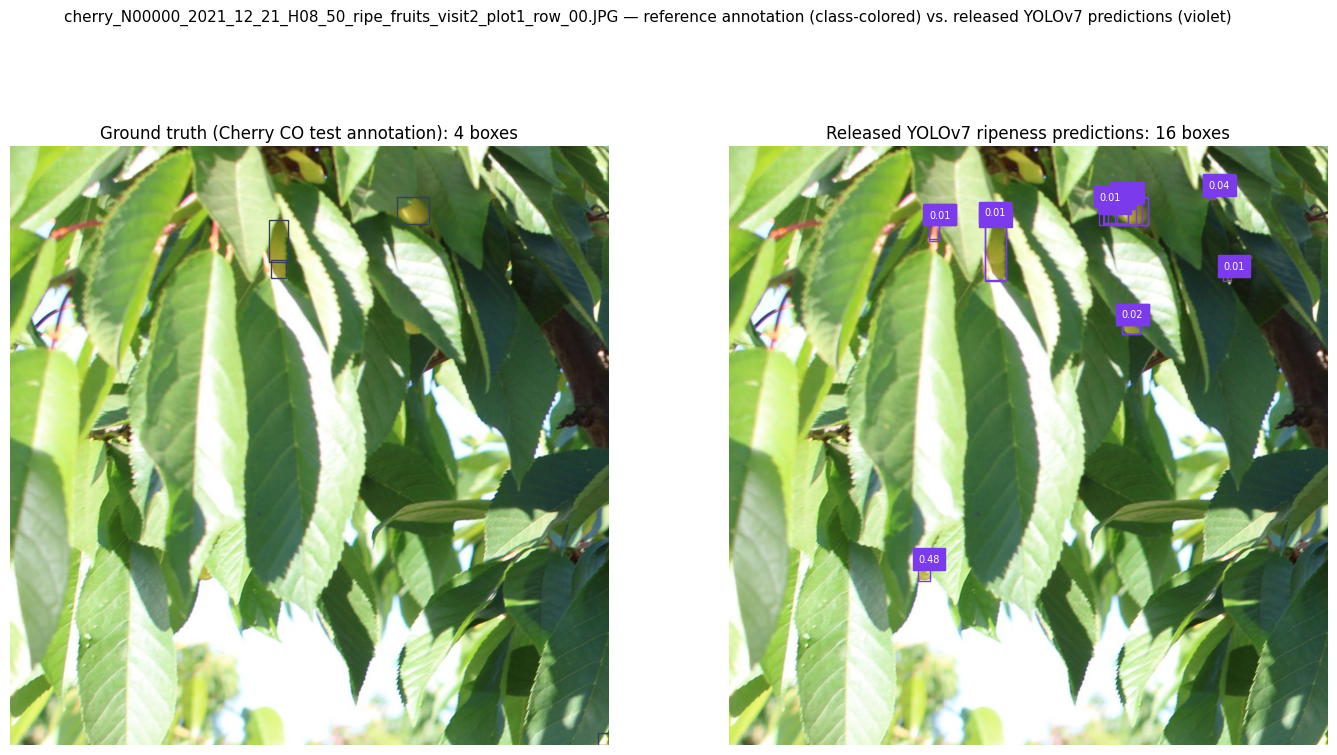

In [ ]:
import shutil, sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpl_patches
from PIL import Image

img = np.asarray(Image.open('/content/sample_test_image.JPG'))
print('sample image:', SAMPLE_IMG_NAME, img.shape)

sys.path.insert(0, str(CODE_DIR))
import yolo_utils_eval  # authors' module, verbatim from commit 6ed6b9f

os.makedirs('/content/preview_pred', exist_ok=True)
shutil.copy(f'/content/work_dir/yolov7/{SAMPLE_STEM}.txt', '/content/preview_pred/')
preview_preds = yolo_utils_eval.load_bbox_file_dicts(coco.imgs, '/content/preview_pred')
sample_preds = [a for a in preview_preds if a['file_name'] == SAMPLE_STEM + '.JPG']

id_images = {info['file_name']: i for i, (_, info) in enumerate(coco.imgs.items())}
sample_id = id_images[SAMPLE_STEM + '.JPG']
gt_anns = coco.loadAnns(coco.getAnnIds(imgIds=[sample_id]))
cat_name = {c['id']: c['name'] for c in coco.loadCats()}
class_colors = {'ripe': '#e11d48', 'unripe': '#f59e0b', 'green': '#10b981'}

fig, axes = plt.subplots(1, 2, figsize=(17, 9))
ax = axes[0]
ax.imshow(img)
for a in gt_anns:
    x, y, w, h = a['bbox']
    ax.add_patch(mpl_patches.Rectangle((x, y), w, h, fill=False,
                 edgecolor=class_colors.get(cat_name.get(a['category_id']), '#334155'), linewidth=1.0))
ax.set_title(f'Ground truth (Cherry CO test annotation): {len(gt_anns)} boxes')
ax = axes[1]
ax.imshow(img)
for a in sample_preds:
    x, y, w, h = a['bbox']
    ax.add_patch(mpl_patches.Rectangle((x, y), w, h, fill=False, edgecolor='#7c3aed', linewidth=1.0))
    ax.text(x, max(y - 5, 10), f"{a['score']:.2f}", color='white', fontsize=7,
            backgroundcolor='#7c3aed')
ax.set_title(f'Released YOLOv7 ripeness predictions: {len(sample_preds)} boxes')
for ax in axes:
    ax.axis('off')
fig.suptitle(f'{SAMPLE_IMG_NAME} — reference annotation (class-colored) vs. released YOLOv7 predictions (violet)',
             fontsize=11)
plt.savefig('/content/preview_gt_vs_yolov7.png', dpi=110, bbox_inches='tight')
plt.show()

#

In [ ]:
predictions = yolo_utils_eval.load_bbox_file_dicts(coco.imgs, PRED_DIR)
print('prediction boxes parsed:', len(predictions))
print('files with predictions referenced in gt:', len({a['file_name'] for a in predictions}))
print('category ids present:', sorted({a['category_id'] for a in predictions}))
coco_det = coco.loadRes(predictions)
print('loaded via COCO.loadRes (bbox result type)')

prediction boxes parsed: 12054
files with predictions referenced in gt: 563
category ids present: [1, 2, 3]
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
loaded via COCO.loadRes (bbox result type)


#

In [ ]:
import contextlib, io

import numpy as np
from pycocotools.cocoeval import COCOeval

def evaluate_metric(metric):
    # Exact parameterization of main.py::evaluate_det_segm (commit 6ed6b9f).
    iou_type = 'bbox' if metric == 'proposal' else metric
    cocoEval = COCOeval(coco, coco_det, iou_type)
    cocoEval.params.catIds = cat_ids                        # main.py:176
    cocoEval.params.imgIds = img_ids                        # main.py:177
    cocoEval.params.maxDets = [100, 300, 1000]              # main.py:178
    cocoEval.params.iouThrs = np.linspace(.5, 0.95, 10)     # main.py:118-119
    if metric == 'proposal':
        cocoEval.params.useCats = 0                         # main.py:202
    cocoEval.evaluate(); cocoEval.accumulate()
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        cocoEval.summarize()
    print(buf.getvalue())
    return cocoEval

eval_proposal = evaluate_metric('proposal')
AR_ITEMS = ['AR@100', 'AR@300', 'AR@1000', 'AR_s@1000', 'AR_m@1000', 'AR_l@1000']  # main.py:212-216
proposal_results = {k: float(f'{eval_proposal.stats[6 + i]:.3f}') for i, k in enumerate(AR_ITEMS)}
proposal_results

Running per image evaluation...
Evaluate annotation type *bbox*


DONE (t=2.47s).
Accumulating evaluation results...


DONE (t=0.30s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.590
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.855
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.682
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.451
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.676
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.698
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.700
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.700
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.599
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.764
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.837



{'AR@100': 0.698,
 'AR@300': 0.7,
 'AR@1000': 0.7,
 'AR_s@1000': 0.599,
 'AR_m@1000': 0.764,
 'AR_l@1000': 0.837}

#

In [ ]:
eval_bbox = evaluate_metric('bbox')
BBOX_ITEMS = ['mAP', 'mAP_50', 'mAP_75', 'mAP_s', 'mAP_m', 'mAP_l']  # main.py:266-269
import numpy as np
bbox_results = {k: float(f'{eval_bbox.stats[i]:.3f}') for i, k in enumerate(BBOX_ITEMS)}

precisions = eval_bbox.eval['precision']  # (iou, recall, class, area, maxDets)
assert len(cat_ids) == precisions.shape[2]
classwise = []
for idx, catId in enumerate(cat_ids):
    name = coco.loadCats(catId)[0]['name']
    precision = precisions[:, :, idx, 0, -1]
    precision = precision[precision > -1]
    ap = float(np.mean(precision)) if precision.size else float('nan')
    classwise.append((name, round(ap, 3)))
print('bbox mAP:', bbox_results)
print('classwise AP:', classwise)

Running per image evaluation...
Evaluate annotation type *bbox*


DONE (t=2.51s).
Accumulating evaluation results...


DONE (t=0.59s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.540
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.781
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.628
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.416
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.631
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.482
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.680
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.576
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.751
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.743

bbox mAP: {'mA

#

In [ ]:
import pandas as pd

rows = ([{'eval': 'proposal (useCats=0, README command)', 'metric': k, 'value': v} for k, v in proposal_results.items()] +
        [{'eval': 'bbox (useCats=1, additional view)', 'metric': k, 'value': v} for k, v in bbox_results.items()])
results_df = pd.DataFrame(rows)
display(results_df)
for name, ap in classwise:
    print(f'classwise AP [{name:>7s}] = {ap:.3f}')
results_df.to_csv('/content/cherryco_yolov7_eval_results.csv', index=False)
print('saved: /content/cherryco_yolov7_eval_results.csv')

,eval,metric,value
0,"proposal (useCats=0, README command)",AR@100,0.698
1,"proposal (useCats=0, README command)",AR@300,0.700
2,"proposal (useCats=0, README command)",AR@1000,0.700
3,"proposal (useCats=0, README command)",AR_s@1000,0.599
4,"proposal (useCats=0, README command)",AR_m@1000,0.764
5,"proposal (useCats=0, README command)",AR_l@1000,0.837
6,"bbox (useCats=1, additional view)",mAP,0.540
7,"bbox (useCats=1, additional view)",mAP_50,0.781
8,"bbox (useCats=1, additional view)",mAP_75,0.628
9,"bbox (useCats=1, additional view)",mAP_s,0.416


classwise AP [   ripe] = 0.568
classwise AP [ unripe] = 0.539
classwise AP [  green] = 0.514
saved: /content/cherryco_yolov7_eval_results.csv


#

## Interpretation, differences from the paper, and validation record

**What was executed.** The authors' released YOLOv7 ripeness predictions for the Cherry CO **test** split were rescored against the official COCO-format ground-truth annotations using the authors' own parsing code (`yolo_utils_eval.py`, verbatim) and the exact COCOeval parameterization of their `main.py::evaluate_det_segm` — first the README-documented `--eval proposal` (class-agnostic AR), then the standard `bbox` metric with per-class AP. One test image is shown with reference annotation vs. released predictions.

**Differences / limitations (important).**
- This is a **partial** reproduction: the evaluation/scoring step only. Training, inference and the paper's full benchmark tables are out of scope; no trained weights are public.
- The mmdet-2.x dataset/config wrapper was replaced by a pycocotools equivalent (AI-assisted glue); the metric computation itself is the same `pycocotools` `COCOeval` that mmdet 2.x re-exports, with identical parameters cited line-by-line.
- The article is closed access (IEEE RAL 2024): computed values are **not** compared against the paper's published tables, and should not be quoted as the paper's results.
- The released `work_dir/yolov7` folder covers a subset of the test images; images without released predictions count as false negatives in AR (the authors' code evaluates exactly this folder).
- No LICENSE file in the evaluation repository and no dataset license statement on the project page; redistribution terms are unverified — please check before reuse.

**Sources.** Code: `github.com/LuisCossioUOH/evaluation_Cherry_CO` @ `6ed6b9fc3a3f93cbe68b414ba5d3a83bc8087082` (fetched in this notebook, blob-SHA verified). Data: official Cherry CO Drive folder `1_-sOfq6KC62i9_rKeMwwGba5uBOaagaj` (test split), linked from https://rodrigo.verschae.org/cherryCO/. Paper: DOI 10.1109/LRA.2024.3393214.

*日本語: 本ノートブックは「評価（採点）」部分のみの部分再現です。著者公開の予測と正解アノテーションから指標を計算したものであり、論文の掲載値の引用ではありません。学習・推論は対象外（重み未公開）。リポジトリ・データセットにはライセンス表記がないため、再配布前に確認してください。*